In [1]:
%matplotlib inline

Classifying Names with a Character-Level RNN
==============================================================

Borrow from [Sean Robertson](https://github.com/spro)

Preparing Torch
===============

Set up torch to default to the right device use GPU acceleration
depending on your hardware (CPU or CUDA).


In [2]:
import torch

# Check if CUDA is available
device = torch.device('cpu')
if torch.cuda.is_available():
    device = torch.device('cuda')

print('Using PyTorch version:', torch.__version__, ' Device:', device)

Using PyTorch version: 2.7.1+cu118  Device: cuda


Preparing the Data
==================

Download the data from
[here](https://download.pytorch.org/tutorial/data.zip) and extract it to
the current directory.

Included in the `data/names` directory are 18 text files named as
`[Language].txt`. Each file contains a bunch of names, one name per
line, mostly romanized (but we still need to convert from Unicode to
ASCII).

The first step is to define and clean our data. Initially, we need to
convert Unicode to plain ASCII to limit the RNN input layers. This is
accomplished by converting Unicode strings to ASCII and allowing only a
small set of allowed characters.


In [3]:
import string
import unicodedata

# We can use "_" to represent an out-of-vocabulary character, that is, any character we are not handling in our model
allowed_characters = string.ascii_letters + " .,;'" + "_"
n_letters = len(allowed_characters)

# Turn a Unicode string to plain ASCII, thanks to https://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in allowed_characters
    )

Here\'s an example of converting a unicode alphabet name to plain ASCII.
This simplifies the input layer


In [4]:
print (f"converting 'Ślusàrski' to {unicodeToAscii('Ślusàrski')}")

converting 'Ślusàrski' to Slusarski


Turning Names into Tensors
==========================

Now that we have all the names organized, we need to turn them into
Tensors to make any use of them.

To represent a single letter, we use a \"one-hot vector\" of size
`<1 x n_letters>`. A one-hot vector is filled with 0s except for a 1 at
index of the current letter, e.g. `"b" = <0 1 0 0 0 ...>`.

To make a word we join a bunch of those into a 2D matrix
`<line_length x 1 x n_letters>`.

That extra 1 dimension is because PyTorch assumes everything is in
batches - we\'re just using a batch size of 1 here.


In [5]:
# Find letter index from all_letters, e.g. "a" = 0
def letterToIndex(letter):
    # return our out-of-vocabulary character if we encounter a letter unknown to our model
    if letter not in allowed_characters:
        return allowed_characters.find("_")
    else:
        return allowed_characters.find(letter)

# Turn a line into a <line_length x 1 x n_letters>,
# or an array of one-hot letter vectors
def lineToTensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)
    for li, letter in enumerate(line):
        tensor[li][0][letterToIndex(letter)] = 1
    return tensor

Here are some examples of how to use `lineToTensor()` for a single and
multiple character string.


In [6]:
print (f"The letter 'a' becomes {lineToTensor('a')}") #notice that the first position in the tensor = 1
print (f"The name 'Ahn' becomes {lineToTensor('Ahn')}") #notice 'A' sets the 27th index to 1

The letter 'a' becomes tensor([[[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]]])
The name 'Ahn' becomes tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0

Congratulations, you have built the foundational tensor objects for this
learning task! You can use a similar approach for other RNN tasks with
text.

Next, we need to combine all our examples into a dataset so we can
train, test and validate our models. For this, we will use the [Dataset
and
DataLoader](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html)
classes to hold our dataset. Each Dataset needs to implement three
functions: `__init__`, `__len__`, and `__getitem__`.


In [7]:
from io import open
import glob
import os
import time

import torch
from torch.utils.data import Dataset

class NamesDataset(Dataset):

    def __init__(self, data_dir):
        self.data_dir = data_dir #for provenance of the dataset
        self.load_time = time.localtime #for provenance of the dataset
        labels_set = set() #set of all classes

        self.data = []
        self.data_tensors = []
        self.labels = []
        self.labels_tensors = []

        #read all the ``.txt`` files in the specified directory
        text_files = glob.glob(os.path.join(data_dir, '*.txt'))
        for filename in text_files:
            label = os.path.splitext(os.path.basename(filename))[0]
            labels_set.add(label)
            lines = open(filename, encoding='utf-8').read().strip().split('\n')
            for name in lines:
                self.data.append(name)
                self.data_tensors.append(lineToTensor(name))
                self.labels.append(label)

        #Cache the tensor representation of the labels
        self.labels_uniq = list(labels_set)
        for idx in range(len(self.labels)):
            temp_tensor = torch.tensor([self.labels_uniq.index(self.labels[idx])], dtype=torch.long)
            self.labels_tensors.append(temp_tensor)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        data_item = self.data[idx]
        data_label = self.labels[idx]
        data_tensor = self.data_tensors[idx]
        label_tensor = self.labels_tensors[idx]

        return label_tensor, data_tensor, data_label, data_item

Here we can load our example data into the `NamesDataset`


In [8]:
alldata = NamesDataset("data/names")
print(f"loaded {len(alldata)} items of data")
print(f"example = {alldata[0]}")

loaded 20074 items of data
example = (tensor([3]), tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 1., 0., 0., 0., 0., 0., 

Using the dataset object allows us to easily split the data into train and test sets. Here we create a 80/20

:   split but the `torch.utils.data` has more useful utilities. Here we
    specify a generator since we need to use the

same device as PyTorch defaults to above.


In [9]:
train_set, test_set = torch.utils.data.random_split(alldata, [.85, .15], generator=torch.Generator().manual_seed(2024))

print(f"train examples = {len(train_set)}, validation examples = {len(test_set)}")

train examples = 17063, validation examples = 3011


Now we have a basic dataset containing **20074** examples where each
example is a pairing of label and name. We have also split the dataset
into training and testing so we can validate the model that we build.


Creating the Network
====================

Before autograd, creating a recurrent neural network in Torch involved
cloning the parameters of a layer over several timesteps. The layers
held hidden state and gradients which are now entirely handled by the
graph itself. This means you can implement a RNN in a very \"pure\" way,
as regular feed-forward layers.

This CharRNN class implements an RNN with three components. First, we
use the [nn.RNN
implementation](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html).
Next, we define a layer that maps the RNN hidden layers to our output.
And finally, we apply a `softmax` function. Using `nn.RNN` leads to a
significant improvement in performance, such as cuDNN-accelerated
kernels, versus implementing each layer as a `nn.Linear`. It also
simplifies the implementation in `forward()`.


In [10]:
import torch.nn as nn
import torch.nn.functional as F

class CharRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharRNN, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, line_tensor):
        rnn_out, hidden = self.rnn(line_tensor)
        output = self.h2o(hidden[0])
        output = self.softmax(output)

        return output

We can then create an RNN with 58 input nodes, 128 hidden nodes, and 18
outputs:


In [11]:
n_hidden = 128
rnn = CharRNN(n_letters, n_hidden, len(alldata.labels_uniq))
print(rnn)

CharRNN(
  (rnn): RNN(58, 128)
  (h2o): Linear(in_features=128, out_features=18, bias=True)
  (softmax): LogSoftmax(dim=1)
)


After that we can pass our Tensor to the RNN to obtain a predicted
output. Subsequently, we use a helper function, `label_from_output`, to
derive a text label for the class.


In [12]:
def label_from_output(output, output_labels):
    top_n, top_i = output.topk(1)
    label_i = top_i[0].item()
    return output_labels[label_i], label_i

input = lineToTensor('Albert')
output = rnn(input) #this is equivalent to ``output = rnn.forward(input)``
print(output)
print(label_from_output(output, alldata.labels_uniq))

tensor([[-2.9567, -2.8517, -2.8520, -2.8404, -2.8925, -2.8952, -2.8221, -2.8639,
         -3.0787, -2.8421, -2.9152, -3.0043, -2.9303, -2.8570, -2.8167, -2.8911,
         -2.9477, -2.8102]], grad_fn=<LogSoftmaxBackward0>)
('Irish', 17)


Training
========


Training the Network
====================

Now all it takes to train this network is show it a bunch of examples,
have it make guesses, and tell it if it\'s wrong.

We do this by defining a `train()` function which trains the model on a
given dataset using minibatches. RNNs RNNs are trained similarly to
other networks; therefore, for completeness, we include a batched
training method here. The loop (`for i in batch`) computes the losses
for each of the items in the batch before adjusting the weights. This
operation is repeated until the number of epochs is reached.


In [13]:
import random
import numpy as np

def train(rnn, training_data, n_epoch = 10, n_batch_size = 64, report_every = 50, learning_rate = 0.2, criterion = nn.NLLLoss()):
    """
    Learn on a batch of training_data for a specified number of iterations and reporting thresholds
    """
    # Keep track of losses for plotting
    current_loss = 0
    all_losses = []
    rnn.train()
    optimizer = torch.optim.SGD(rnn.parameters(), lr=learning_rate)

    start = time.time()
    print(f"training on data set with n = {len(training_data)}")

    for iter in range(1, n_epoch + 1):
        rnn.zero_grad() # clear the gradients

        # create some minibatches
        # we cannot use dataloaders because each of our names is a different length
        batches = list(range(len(training_data)))
        random.shuffle(batches)
        batches = np.array_split(batches, len(batches) //n_batch_size )

        for idx, batch in enumerate(batches):
            batch_loss = 0
            for i in batch: #for each example in this batch
                (label_tensor, text_tensor, label, text) = training_data[i]
                output = rnn.forward(text_tensor)
                loss = criterion(output, label_tensor)
                batch_loss += loss

            # optimize parameters
            batch_loss.backward()
            nn.utils.clip_grad_norm_(rnn.parameters(), 3)
            optimizer.step()
            optimizer.zero_grad()

            current_loss += batch_loss.item() / len(batch)

        all_losses.append(current_loss / len(batches) )
        if iter % report_every == 0:
            print(f"{iter} ({iter / n_epoch:.0%}): \t average batch loss = {all_losses[-1]}")
        current_loss = 0

    return all_losses

We can now train a dataset with minibatches for a specified number of
epochs. The number of epochs for this example is reduced to speed up the
build. You can get better results with different parameters.


In [14]:
start = time.time()
all_losses = train(rnn, train_set, n_epoch=27, learning_rate=0.15, report_every=5)
end = time.time()
print(f"training took {end-start}s")

training on data set with n = 17063
5 (19%): 	 average batch loss = 0.88395850749082
10 (37%): 	 average batch loss = 0.689922147423908
15 (56%): 	 average batch loss = 0.5802035775244615
20 (74%): 	 average batch loss = 0.49548376958931434
25 (93%): 	 average batch loss = 0.436830382285227
training took 523.818811416626s


Plotting the Results
====================

Plotting the historical loss from `all_losses` shows the network
learning:


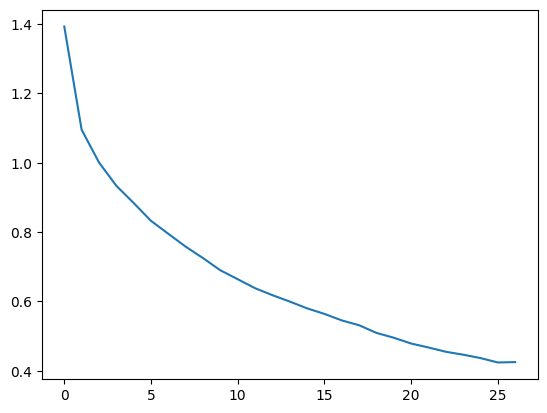

In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure()
plt.plot(all_losses)
plt.show()

Evaluating the Results
======================

To see how well the network performs on different categories, we will
create a confusion matrix, indicating for every actual language (rows)
which language the network guesses (columns). To calculate the confusion
matrix a bunch of samples are run through the network with `evaluate()`,
which is the same as `train()` minus the backprop.


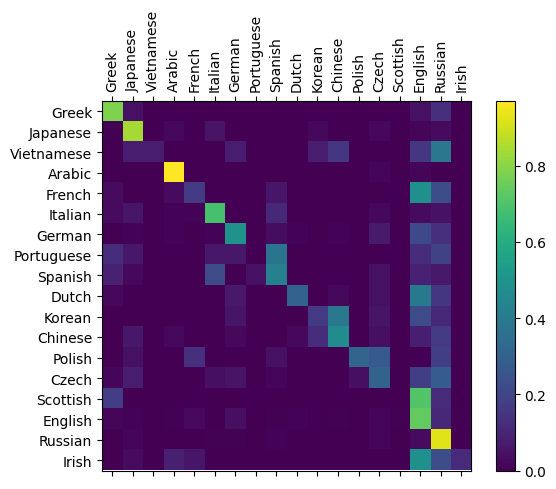

In [16]:
def evaluate(rnn, testing_data, classes):
    confusion = torch.zeros(len(classes), len(classes))

    rnn.eval() #set to eval mode
    with torch.no_grad(): # do not record the gradients during eval phase
        for i in range(len(testing_data)):
            (label_tensor, text_tensor, label, text) = testing_data[i]
            output = rnn(text_tensor)
            guess, guess_i = label_from_output(output, classes)
            label_i = classes.index(label)
            confusion[label_i][guess_i] += 1

    # Normalize by dividing every row by its sum
    for i in range(len(classes)):
        denom = confusion[i].sum()
        if denom > 0:
            confusion[i] = confusion[i] / denom

    # Set up plot
    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(confusion.cpu().numpy()) #numpy uses cpu here so we need to use a cpu version
    fig.colorbar(cax)

    # Set up axes
    ax.set_xticks(np.arange(len(classes)), labels=classes, rotation=90)
    ax.set_yticks(np.arange(len(classes)), labels=classes)

    # Force label at every tick
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    # sphinx_gallery_thumbnail_number = 2
    plt.show()



evaluate(rnn, test_set, classes=alldata.labels_uniq)

You can pick out bright spots off the main axis that show which
languages it guesses incorrectly, e.g. Chinese for Korean, and Spanish
for Italian. It seems to do very well with Greek, and very poorly with
English (perhaps because of overlap with other languages).


Exercises
=========

-   Get better results with a bigger and/or better shaped network
    -   Adjust the hyperparameters to enhance performance, such as
        changing the number of epochs, batch size, and learning rate
    -   Try the `nn.LSTM` and `nn.GRU` layers
    -   Modify the size of the layers, such as increasing or decreasing
        the number of hidden nodes or adding additional linear layers
    -   Combine multiple of these RNNs as a higher level network
-   Try with a different dataset of line -\> label, for example:
    -   Any word -\> language
    -   First name -\> gender
    -   Character name -\> writer
    -   Page title -\> blog or subreddit


---
## 统一对比实验：RNN vs LSTM（名字识别）

上面是老师提供的原始 RNN 教程。下面按作业要求加入\*\*自己实现的 LSTM\*\*（手写门控，对应加分项），在同一套协议下与 RNN 对比。

结构（沿用 exp1 风格）：
- 模型定义在 [`models.py`](models.py)（`NameRNN` / `NameLSTM`，统一接口 `forward(line_tensor) -> (1, n_classes)`）；
- 数据 / 训练 / 评估在 [`train_utils.py`](train_utils.py)（训练循环沿用老师写法：NLLLoss + SGD + 伪 batch 累加 + 梯度裁剪，额外记录每个 epoch 的验证准确率）；
- 本节负责：构建模型 → 打印结构 → 训练 → 可视化（loss 曲线 / 准确率曲线 / 混淆矩阵）+ 对比。

In [17]:
import importlib, json, os, time
import torch
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

import models, train_utils
importlib.reload(models); importlib.reload(train_utils)
from models import build_model
from train_utils import (load_data, train_model, evaluate,
                         compute_confusion, count_parameters, set_seed)

CONFIG = {
    'models': ['rnn', 'lstm'],
    'hidden_size': 128,
    'n_epoch': 15,        # 手写 LSTM 在 CPU 上较慢；想先跑通可改小（如 5）
    'lr': 0.15,
    'batch_size': 64,
    'seed': 2024,
}
DEVICE = 'cpu'            # 名字短、逐样本前向，CPU 即可（GPU 逐样本传输反而未必更快）
HIST_PATH = './histories.json'
PLOT_LABEL = {'rnn': 'RNN', 'lstm': 'LSTM'}

set_seed(CONFIG['seed'])
train_data, val_data, classes, n_letters = load_data(root='data', seed=CONFIG['seed'])
n_classes = len(classes)
print(f'train={len(train_data)}  val={len(val_data)}  classes={n_classes}  n_letters={n_letters}')

def model_iter():
    for m in CONFIG['models']:
        if m in results:
            yield m, results[m]

train=17063  val=3011  classes=18  n_letters=58


### 网络结构与参数量

打印两个模型的结构（`print(net)`）与可训练参数量。

In [18]:
for m in CONFIG['models']:
    net = build_model(m, n_letters, CONFIG['hidden_size'], n_classes)
    print('=' * 60)
    print(f'[{m.upper()}] 可训练参数量 = {count_parameters(net):,}')
    print(net)

[RNN] 可训练参数量 = 26,386
NameRNN(
  (rnn): RNN(58, 128)
  (h2o): Linear(in_features=128, out_features=18, bias=True)
  (softmax): LogSoftmax(dim=1)
)
[LSTM] 可训练参数量 = 98,066
NameLSTM(
  (x2h): Linear(in_features=186, out_features=512, bias=True)
  (h2o): Linear(in_features=128, out_features=18, bias=True)
  (softmax): LogSoftmax(dim=1)
)


### 训练两个模型

> 逐样本训练，手写 LSTM 较慢；`histories.json` 存在时默认直接加载跳过训练（`FORCE_RETRAIN=True` 可强制重训）。

In [19]:
FORCE_RETRAIN = False

if (not FORCE_RETRAIN) and os.path.exists(HIST_PATH):
    with open(HIST_PATH, encoding='utf-8') as f:
        results = json.load(f)
    print('已加载', HIST_PATH, '→', [k for k in results if not k.startswith('_')])
else:
    results = {}
    for m in CONFIG['models']:
        print('\n' + '#' * 70); print('# 训练', m.upper()); print('#' * 70)
        set_seed(CONFIG['seed'])
        net = build_model(m, n_letters, CONFIG['hidden_size'], n_classes)
        t0 = time.time()
        hist = train_model(net, train_data, val_data,
                           n_epoch=CONFIG['n_epoch'], n_batch_size=CONFIG['batch_size'],
                           lr=CONFIG['lr'], device=DEVICE, report_every=1)
        elapsed = time.time() - t0
        conf = compute_confusion(net, val_data, n_classes, DEVICE).tolist()
        results[m] = {
            'history': hist,
            'confusion': conf,
            'params': count_parameters(net),
            'best_acc': max(hist['val_acc']),
            'final_acc': hist['val_acc'][-1],
            'train_time_sec': elapsed,
        }
        torch.save(net.state_dict(), f'./ckpt_{m}.pth')
        print(f'==> {m.upper()} done: best_acc={results[m]["best_acc"]:.2f}%  用时 {elapsed/60:.1f} 分钟')
    with open(HIST_PATH, 'w', encoding='utf-8') as f:
        json.dump(results, f, ensure_ascii=False, indent=2)
    print('saved', HIST_PATH)


######################################################################
# 训练 RNN
######################################################################
epoch  1/15  train_loss=1.3763  val_acc=66.85%
epoch  2/15  train_loss=1.0964  val_acc=68.75%
epoch  3/15  train_loss=0.9950  val_acc=71.34%
epoch  4/15  train_loss=0.9368  val_acc=72.14%
epoch  5/15  train_loss=0.8892  val_acc=73.90%
epoch  6/15  train_loss=0.8377  val_acc=73.00%
epoch  7/15  train_loss=0.7997  val_acc=73.93%
epoch  8/15  train_loss=0.7575  val_acc=75.95%
epoch  9/15  train_loss=0.7238  val_acc=74.16%
epoch 10/15  train_loss=0.6977  val_acc=75.99%
epoch 11/15  train_loss=0.6688  val_acc=76.45%
epoch 12/15  train_loss=0.6380  val_acc=78.11%
epoch 13/15  train_loss=0.6175  val_acc=78.74%
epoch 14/15  train_loss=0.5992  val_acc=76.75%
epoch 15/15  train_loss=0.5835  val_acc=78.45%
==> RNN done: best_acc=78.74%  用时 9.2 分钟

######################################################################
# 训练 LSTM
####################

### 可视化对比：loss 曲线 / 准确率曲线 / 混淆矩阵

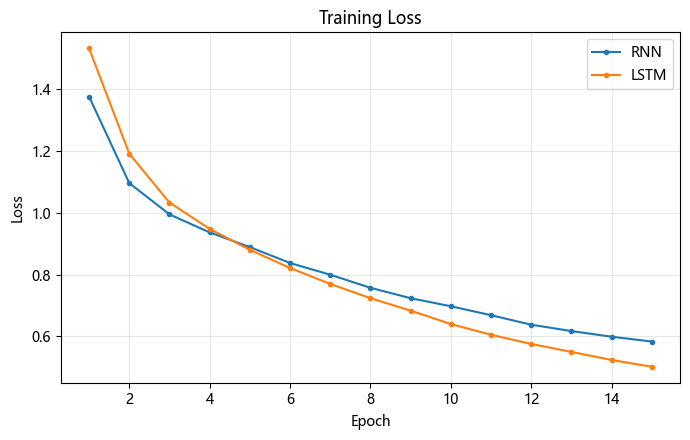

In [20]:
# 训练 loss 曲线
plt.figure(figsize=(7, 4.5))
for m, r in model_iter():
    ex = range(1, len(r['history']['train_loss']) + 1)
    plt.plot(ex, r['history']['train_loss'], marker='o', ms=3, label=PLOT_LABEL[m])
plt.title('Training Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True, alpha=.3); plt.tight_layout(); plt.show()

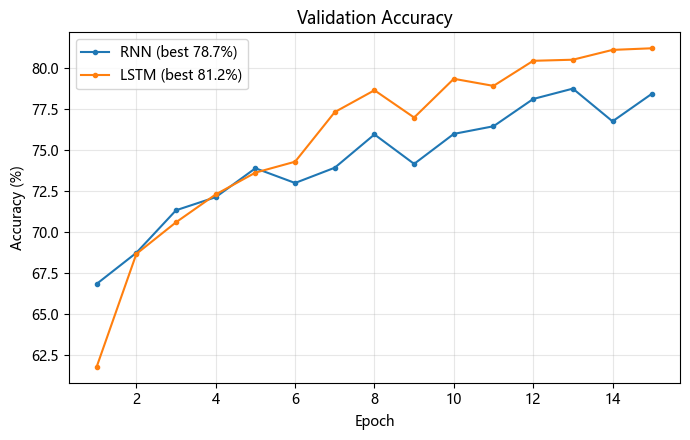

In [21]:
# 验证准确率曲线
plt.figure(figsize=(7, 4.5))
for m, r in model_iter():
    ex = range(1, len(r['history']['val_acc']) + 1)
    plt.plot(ex, r['history']['val_acc'], marker='o', ms=3,
             label=f"{PLOT_LABEL[m]} (best {r['best_acc']:.1f}%)")
plt.title('Validation Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)')
plt.legend(); plt.grid(True, alpha=.3); plt.tight_layout(); plt.show()

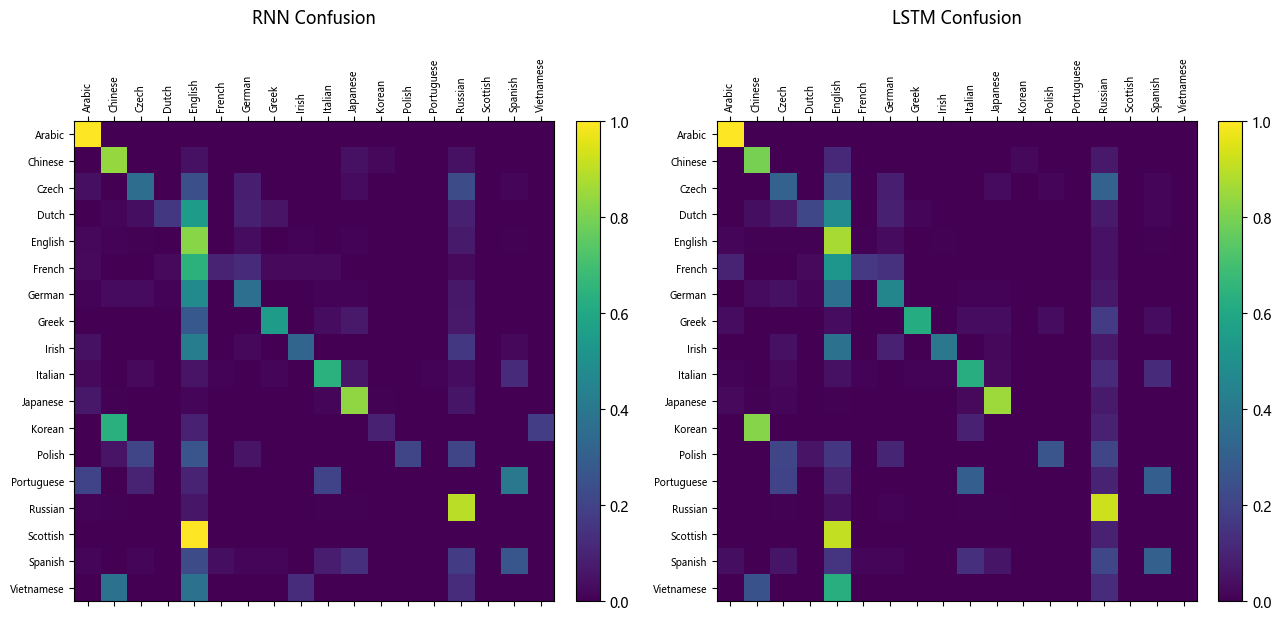

In [22]:
# 混淆矩阵（预测矩阵图），左 RNN 右 LSTM
ms = [m for m, _ in model_iter()]
fig, axes = plt.subplots(1, len(ms), figsize=(6.5 * len(ms), 6))
if len(ms) == 1: axes = [axes]
for ax, m in zip(axes, ms):
    conf = np.array(results[m]['confusion'])
    cax = ax.matshow(conf)
    ax.set_title(f'{PLOT_LABEL[m]} Confusion', pad=24)
    ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes, rotation=90, fontsize=7)
    ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes, fontsize=7)
    fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

In [ ]:
# 汇总表
rows = [{'模型': PLOT_LABEL[m], '参数量': results[m]['params'],
         '最佳准确率(%)': round(results[m]['best_acc'], 2),
         '最终准确率(%)': round(results[m]['final_acc'], 2),
         '耗时(min)': round(results[m]['train_time_sec'] / 60, 1)}
        for m, _ in model_iter()]
try:
    import pandas as pd
    display(pd.DataFrame(rows))
except Exception:
    for r in rows: print(r)

{'模型': 'RNN', '参数量': 26386, '最佳准确率(%)': 78.74, '最终准确率(%)': 78.45, '耗时(min)': 9.2}
{'模型': 'LSTM', '参数量': 98066, '最佳准确率(%)': 81.2, '最终准确率(%)': 81.2, '耗时(min)': 18.5}


: 

### 分析：为什么 LSTM 优于 RNN（报告重点）

- 普通 RNN 仅靠单一隐藏态在时间维反复相乘传播，长序列下梯度易消失/爆炸，难以保留较早字符的信息；
- LSTM 引入\*\*细胞态 $c_t$\*\* 与\*\*输入门 / 遗忘门 / 输出门\*\*，遗忘门让梯度近似线性地沿 $c_t$ 传播（缓解梯度消失），门控可选择性地记住/丢弃信息；
- 因此 LSTM 能更充分利用整段名字的字符依赖，验证准确率与收敛通常优于 RNN（结合上方曲线与混淆矩阵，填入实测数字与具体类别差异）。